# Building the MySQL connection with Python and importing all your data to MySQL Database

In [ ]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items') # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Mayuresh@123',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'D:/Yess Infotech/Data Analytics/Python/Projects/Ecommerce\Dataset'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64



In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import mysql.connector
import os

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Mayuresh@123',
    database='ecommerce'
)
cursor = conn.cursor()

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


# Top 10 Customer Cities by Number of Customers

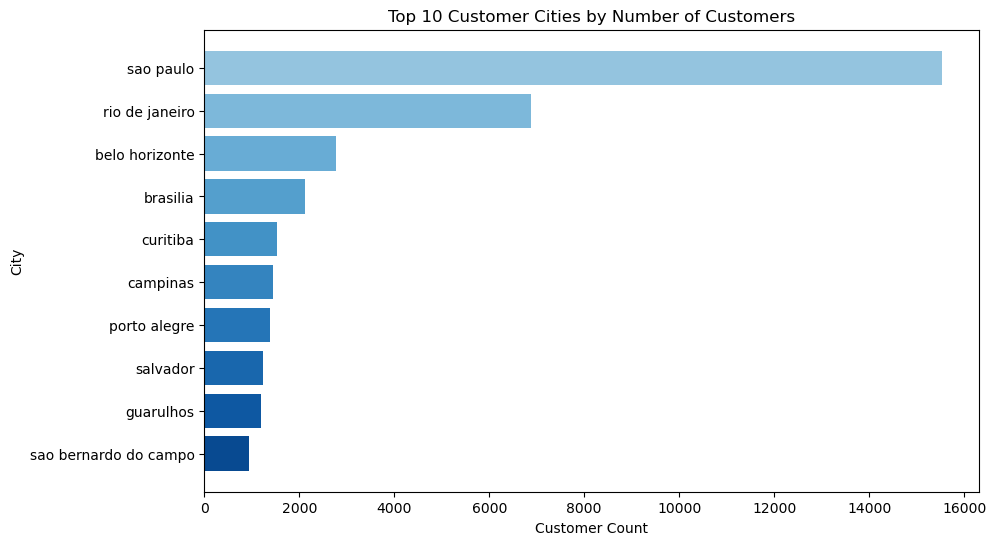

In [9]:
import matplotlib.pyplot as plt
import numpy as np

query = """
SELECT customer_city, COUNT(*) as customer_count
FROM customers
GROUP BY customer_city
ORDER BY customer_count DESC
LIMIT 10
"""

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns=["customer_city", "customer_count"])

# Gradient theme: Deep Blue → Cyan
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

plt.figure(figsize=(10,6))
plt.barh(df["customer_city"], df["customer_count"], color=colors)

plt.xlabel("Customer Count")
plt.ylabel("City")
plt.title("Top 10 Customer Cities by Number of Customers")

plt.gca().invert_yaxis()

plt.show()

# Count the number of orders placed in 2018

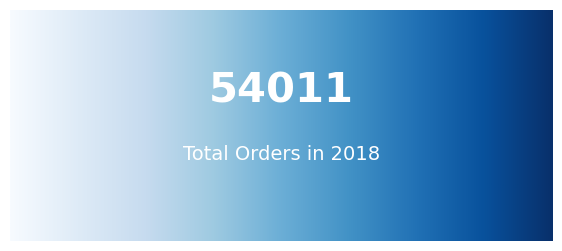

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# SQL Query
query = """
SELECT COUNT(order_id) AS orders_in_2018
FROM orders
WHERE YEAR(order_purchase_timestamp) = 2018
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# Create DataFrame
df = pd.DataFrame(data, columns=["orders_in_2018"])

# Extract Value
value = df["orders_in_2018"][0]

# Create KPI Card
fig, ax = plt.subplots(figsize=(7,3))

# Gradient Background (Deep Blue → Cyan)
gradient = np.linspace(0.3, 1, 256)
gradient = np.vstack((gradient, gradient))

ax.imshow(gradient, aspect='auto', cmap=plt.cm.Blues, extent=[0, 1, 0, 1])

# KPI Number
ax.text(0.5, 0.6, f"{value}",
        fontsize=30,
        ha='center',
        color='white',
        fontweight='bold')

# KPI Title
ax.text(0.5, 0.35, "Total Orders in 2018",
        fontsize=14,
        ha='center',
        color='white')

# Remove Axis
ax.axis('off')

plt.show()

# Find total sales generated across product categories to identify top-performing categories.

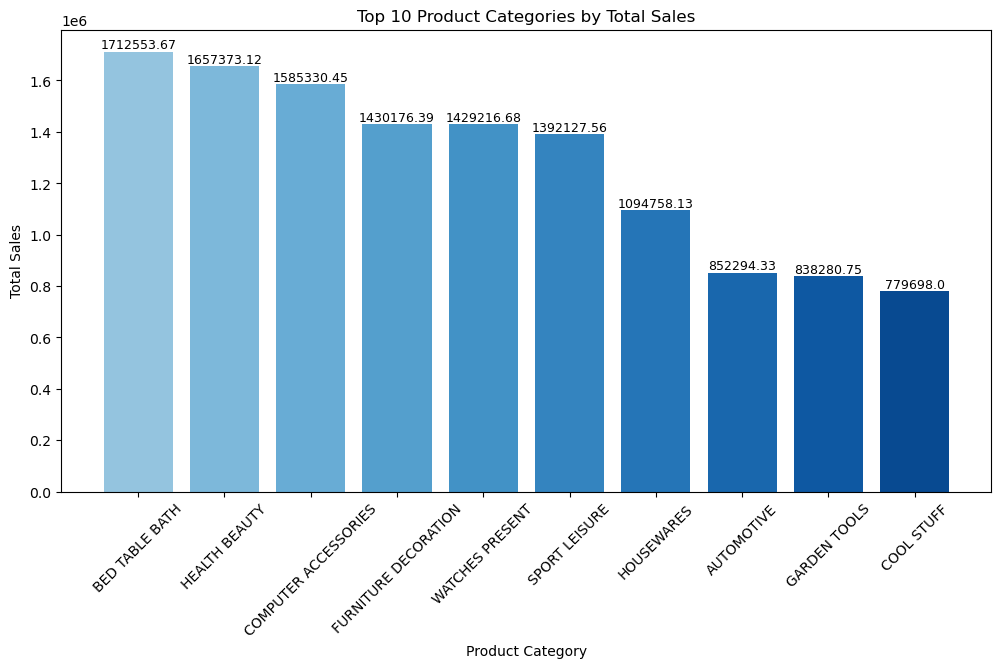

In [18]:
query = """
SELECT 
    UPPER(products.product_category) AS category,
    ROUND(SUM(payments.payment_value), 2) AS sales
FROM products
JOIN order_items
    ON products.product_id = order_items.product_id
JOIN payments
    ON payments.order_id = order_items.order_id
WHERE products.product_category IS NOT NULL
GROUP BY category
ORDER BY sales DESC
LIMIT 10
"""

cursor.execute(query)
data = cursor.fetchall()

# Create DataFrame
df = pd.DataFrame(data, columns=["category", "sales"])

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

# Create Figure
plt.figure(figsize=(12,6))

# Vertical Bar Chart
bars = plt.bar(df["category"], df["sales"], color=colors)

# Labels and Title
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.title("Top 10 Product Categories by Total Sales")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,2),
             ha='center', va='bottom', fontsize=9)

# Show Plot
plt.show()

# Calculate the prcentage of orders that were paid through installaments

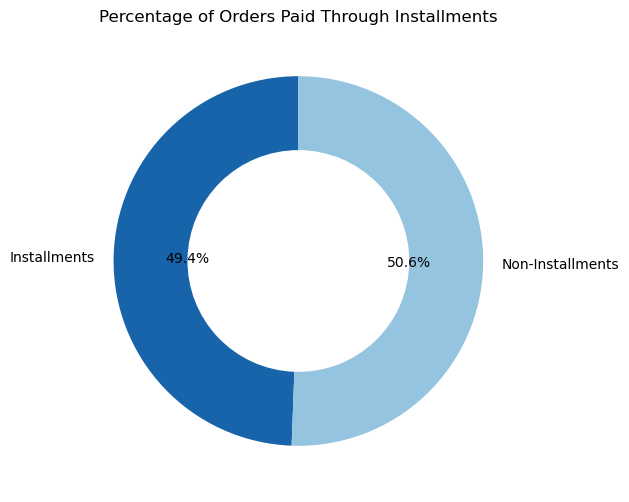

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# SQL Query
query = """
SELECT 
ROUND(
    (SUM(CASE WHEN payment_installments > 1 THEN 1 ELSE 0 END) * 100.0) / COUNT(*),
2
) AS installment_percentage
FROM payments
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# Create DataFrame
df = pd.DataFrame(data, columns=["installment_percentage"])

# Extract Values
value = df["installment_percentage"][0]
remaining = 100 - value

# Donut Chart Data
sizes = [value, remaining]
labels = ['Installments', 'Non-Installments']

# Theme Matching Colors (Deep Blue → Cyan)
colors = [plt.cm.Blues(0.8), plt.cm.Blues(0.4)]

# Create Figure
plt.figure(figsize=(6,6))

# Donut Chart
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4)
)

# Title
plt.title("Percentage of Orders Paid Through Installments")

# Show Plot
plt.show()

# Count the number  of customers from each state

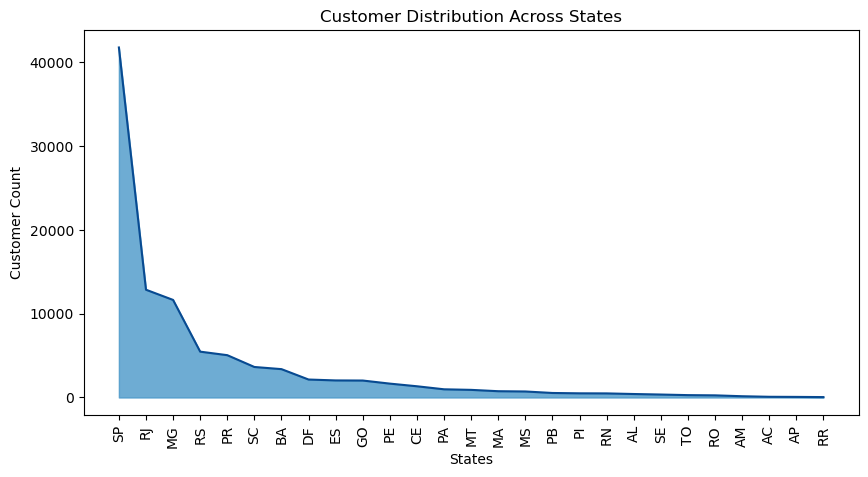

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SQL Query
query = """
SELECT customer_state, COUNT(customer_id) AS customer_count
FROM customers
GROUP BY customer_state
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# Create DataFrame
df = pd.DataFrame(data, columns=["state", "customer_count"])

# Sort values
df = df.sort_values(by="customer_count", ascending=False)

# Theme Gradient
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

# Figure size
plt.figure(figsize=(10,5))

# Area Chart
plt.fill_between(df["state"], df["customer_count"], color=plt.cm.Blues(0.6), alpha=0.8)

# Line for sharpness
plt.plot(df["state"], df["customer_count"], color=plt.cm.Blues(0.9))

# Labels
plt.xlabel("States")
plt.ylabel("Customer Count")
plt.title("Customer Distribution Across States")

# Rotate x labels
plt.xticks(rotation=90)

plt.show()

# Monthly order trend in 20218

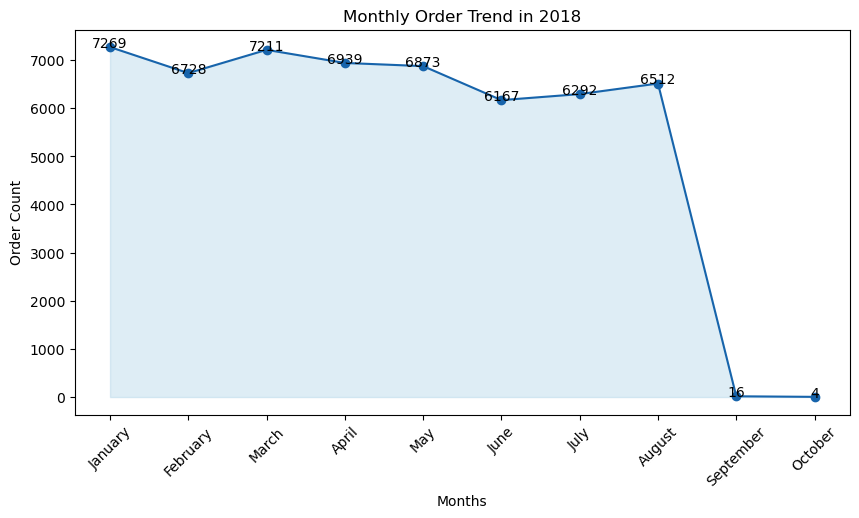

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SQL Query
query = """
SELECT 
    MONTHNAME(order_purchase_timestamp) AS month,
    COUNT(order_id) AS order_count
FROM orders
WHERE YEAR(order_purchase_timestamp) = 2018
GROUP BY MONTH(order_purchase_timestamp), MONTHNAME(order_purchase_timestamp)
ORDER BY MONTH(order_purchase_timestamp)
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# Create DataFrame
df = pd.DataFrame(data, columns=["month", "order_count"])

# Theme color
line_color = plt.cm.Blues(0.8)

# Figure
plt.figure(figsize=(10,5))

# Line Plot
plt.plot(df["month"], df["order_count"], marker='o', color=line_color)

# Fill area for gradient feel
plt.fill_between(df["month"], df["order_count"], color=plt.cm.Blues(0.4), alpha=0.3)

# Labels
plt.xlabel("Months")
plt.ylabel("Order Count")
plt.title("Monthly Order Trend in 2018")

# Rotate labels
plt.xticks(rotation=45)

# Add values
for i, value in enumerate(df["order_count"]):
    plt.text(i, value, str(value), ha='center')

plt.show()

# Identify cities with the highest average products purchased per order

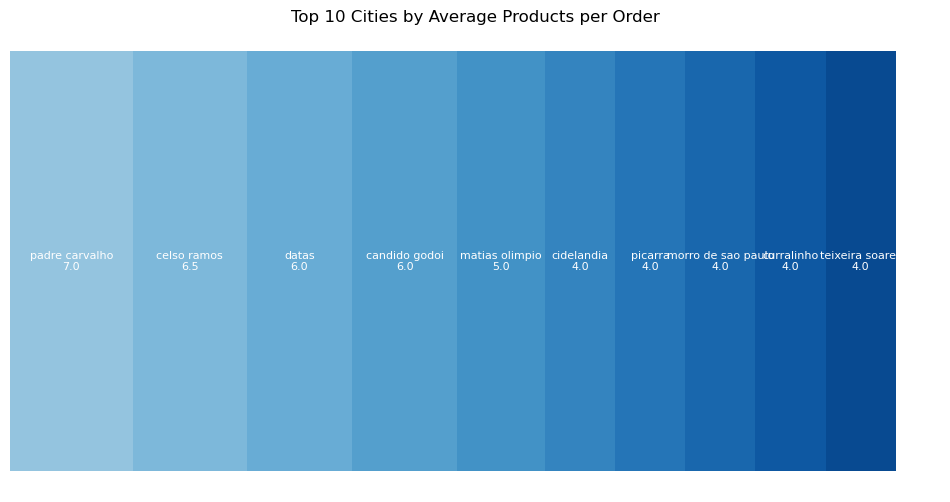

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SQL Query
query = """
WITH count_per_order AS (
    SELECT 
        orders.order_id,
        orders.customer_id,
        COUNT(order_items.order_id) AS product_count
    FROM orders
    JOIN order_items
        ON orders.order_id = order_items.order_id
    GROUP BY orders.order_id, orders.customer_id
)

SELECT 
    customers.customer_city,
    ROUND(AVG(count_per_order.product_count), 2) AS avg_products_per_order
FROM customers
JOIN count_per_order
    ON customers.customer_id = count_per_order.customer_id
GROUP BY customers.customer_city
ORDER BY avg_products_per_order DESC
LIMIT 10
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# DataFrame
df = pd.DataFrame(data, columns=["customer_city", "avg_products_per_order"])

# Convert Decimal to float
df["avg_products_per_order"] = df["avg_products_per_order"].astype(float)

# Gradient colors
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

# Figure
fig, ax = plt.subplots(figsize=(12,6))

# Treemap-like horizontal blocks
left = 0
for i in range(len(df)):
    width = df["avg_products_per_order"].iloc[i]

    ax.barh(
        y=0,
        width=width,
        left=left,
        height=0.5,
        color=colors[i]
    )

    # Label inside block
    ax.text(
        left + width/2,
        0,
        f"{df['customer_city'].iloc[i]}\n{width}",
        ha='center',
        va='center',
        fontsize=8,
        color='white'
    )

    left += width

# Remove axes
ax.axis('off')

# Title
plt.title("Top 10 Cities by Average Products per Order")

plt.show()

# Calculatethe the percentage of total revenue contributed by each product category

In [101]:
query = """select upper(products.product_category) category, 
round((sum(payments.payment_value) / (select sum(payment_value) from payments)) * 100, 2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
order by sales_percentage desc
"""

cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["category", "percentage distribution"])
df.head()

,category,percentage distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93


# Re-establishing the MySQL connection with Python

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import mysql.connector
import os

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Mayuresh@123',
    database='ecommerce'
)
cursor = conn.cursor()

# Identify the correlation between product price  and the number of tiems the product has been purchased

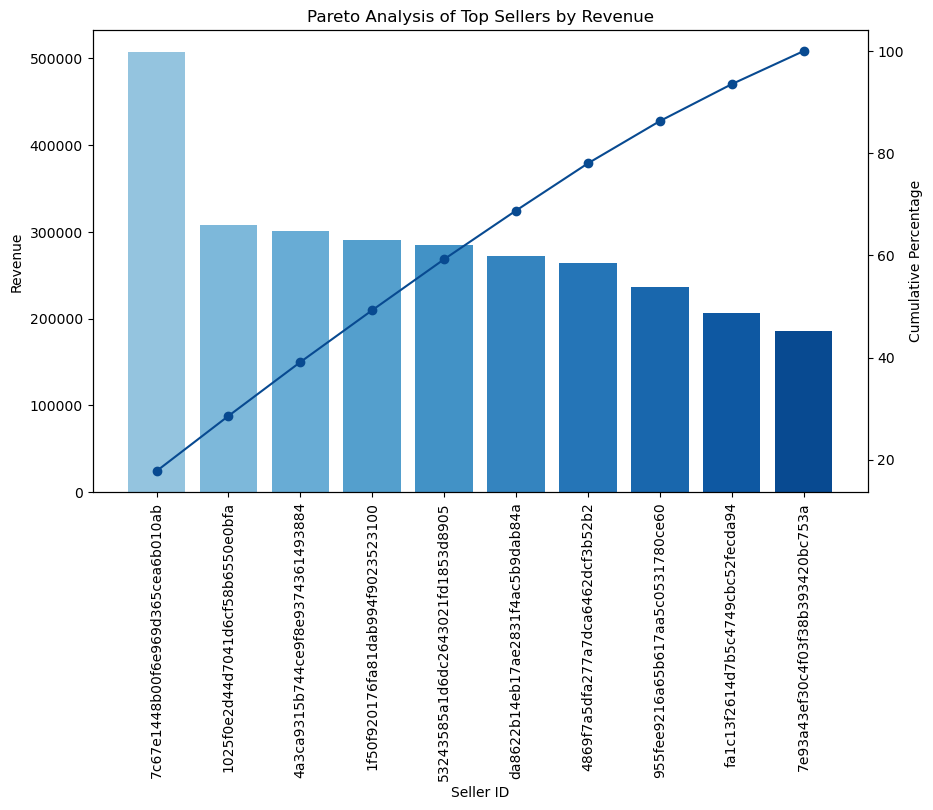

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# SQL Query
query = """
SELECT 
    seller_id,
    revenue,
    DENSE_RANK() OVER (ORDER BY revenue DESC) AS seller_rank
FROM (
    SELECT 
        order_items.seller_id,
        ROUND(SUM(payments.payment_value), 2) AS revenue
    FROM order_items
    JOIN payments
        ON order_items.order_id = payments.order_id
    GROUP BY order_items.seller_id
) AS seller_revenue
LIMIT 10
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# DataFrame
df = pd.DataFrame(data, columns=["seller_id", "revenue", "seller_rank"])

# Cumulative percentage
df["cum_percentage"] = df["revenue"].cumsum() / df["revenue"].sum() * 100

# Theme colors
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

# Figure
fig, ax1 = plt.subplots(figsize=(10,6))

# Bars
ax1.bar(df["seller_id"], df["revenue"], color=colors)

ax1.set_xlabel("Seller ID")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis='x', rotation=90)

# Second axis for cumulative %
ax2 = ax1.twinx()

ax2.plot(df["seller_id"], df["cum_percentage"], color=plt.cm.Blues(0.9), marker='o')

ax2.set_ylabel("Cumulative Percentage")

# Title
plt.title("Pareto Analysis of Top Sellers by Revenue")

plt.show()

# Calculate the  total revenue generated by each seller, and rank by revenue

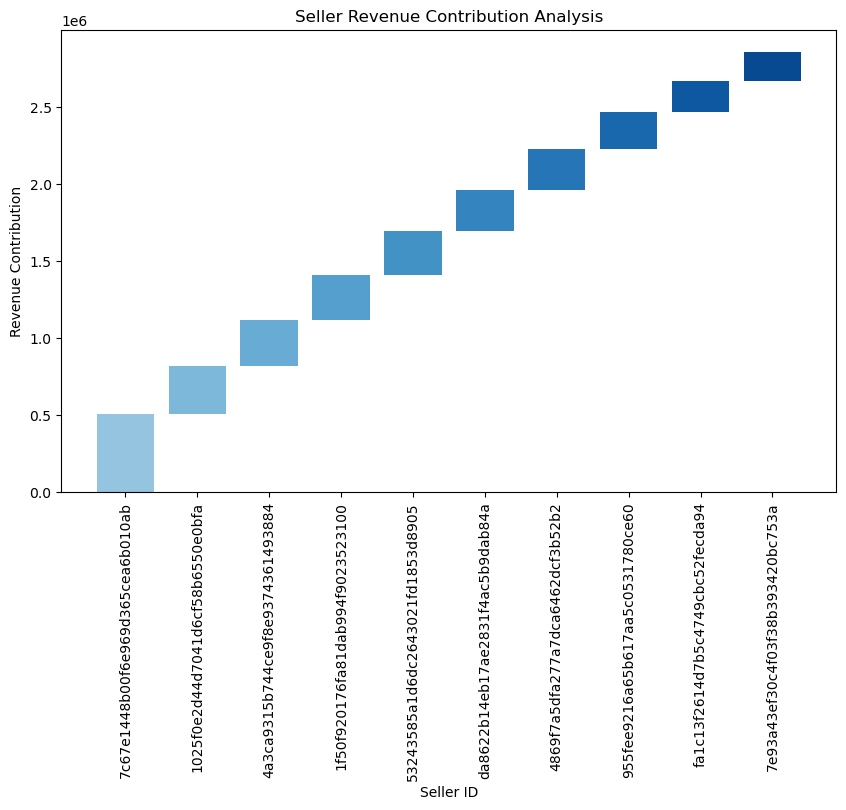

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# SQL Query
query = """
SELECT 
    seller_id,
    revenue,
    DENSE_RANK() OVER (ORDER BY revenue DESC) AS seller_rank
FROM (
    SELECT 
        order_items.seller_id,
        ROUND(SUM(payments.payment_value), 2) AS revenue
    FROM order_items
    JOIN payments
        ON order_items.order_id = payments.order_id
    GROUP BY order_items.seller_id
) AS seller_revenue
LIMIT 10
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# DataFrame
df = pd.DataFrame(data, columns=["seller_id", "revenue", "seller_rank"])

# Sort descending
df = df.sort_values(by="revenue", ascending=False)

# Cumulative positions
df["cumulative"] = df["revenue"].cumsum() - df["revenue"]

# Theme colors
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

# Figure
plt.figure(figsize=(10,6))

# Waterfall bars
for i in range(len(df)):
    plt.bar(
        df["seller_id"].iloc[i],
        df["revenue"].iloc[i],
        bottom=df["cumulative"].iloc[i],
        color=colors[i]
    )

# Labels
plt.xlabel("Seller ID")
plt.ylabel("Revenue Contribution")
plt.title("Seller Revenue Contribution Analysis")

# Rotate labels
plt.xticks(rotation=90)

plt.show()

# Calculate  the moving average of order values for each customer over their order history

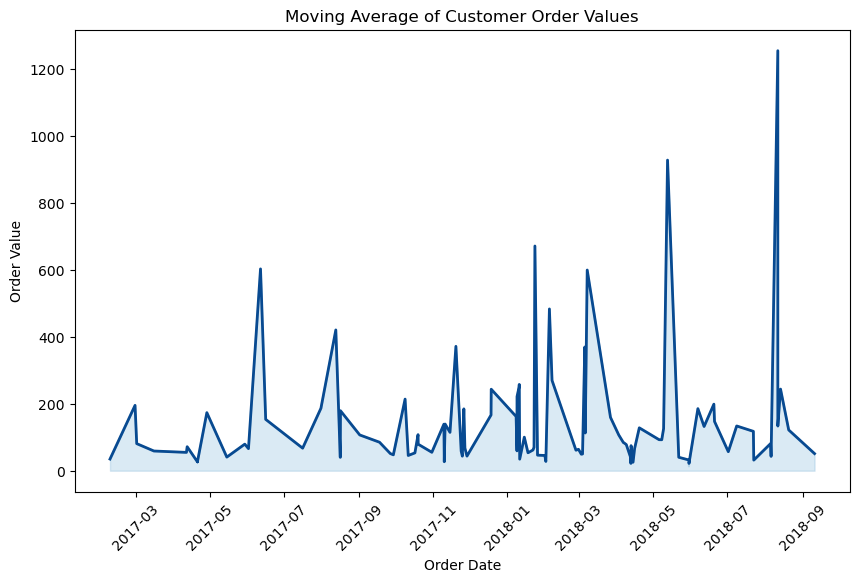

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# SQL Query
query = """
SELECT 
    customer_id,
    order_purchase_timestamp,
    order_value,
    AVG(order_value) OVER (
        PARTITION BY customer_id
        ORDER BY order_purchase_timestamp
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS moving_avg
FROM (
    SELECT 
        orders.customer_id,
        orders.order_purchase_timestamp,
        payments.payment_value AS order_value
    FROM payments
    JOIN orders
        ON payments.order_id = orders.order_id
) AS customer_orders
LIMIT 100
"""

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# DataFrame
df = pd.DataFrame(data, columns=["customer_id", "order_purchase_timestamp", "order_value", "moving_avg"])

# Convert timestamp
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Sort
df = df.sort_values(by="order_purchase_timestamp")

# Figure
plt.figure(figsize=(10,6))

# Raw order values
plt.plot(
    df["order_purchase_timestamp"],
    df["order_value"],
    color=plt.cm.Blues(0.4),
    alpha=0.5
)

# Moving average ribbon line
plt.plot(
    df["order_purchase_timestamp"],
    df["moving_avg"],
    color=plt.cm.Blues(0.9),
    linewidth=2
)

# Ribbon fill
plt.fill_between(
    df["order_purchase_timestamp"],
    df["moving_avg"],
    color=plt.cm.Blues(0.6),
    alpha=0.2
)

# Labels
plt.xlabel("Order Date")
plt.ylabel("Order Value")
plt.title("Moving Average of Customer Order Values")

plt.xticks(rotation=45)

plt.show()

# Track cumulative monthly sales across years to compare revenue growth patterns

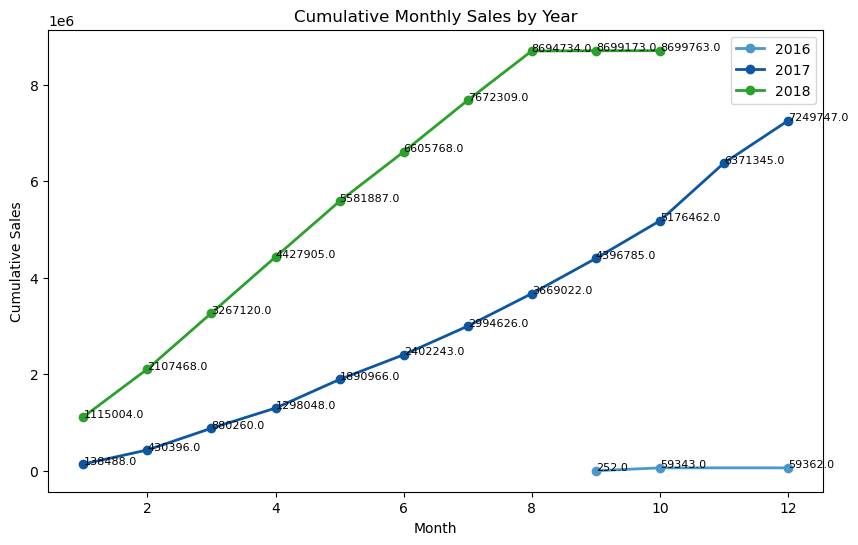

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# Correct DataFrame
df = pd.DataFrame(data, columns=["year", "month", "monthly_sales", "cumulative_sales"])

# Figure
plt.figure(figsize=(10,6))

# Plot each year separately
for year in df["year"].unique():
    yearly_data = df[df["year"] == year]

    plt.plot(
        yearly_data["month"],
        yearly_data["cumulative_sales"],
        marker='o',
        linewidth=2,
        label=year
    )

    # Data labels
    for x, y in zip(yearly_data["month"], yearly_data["cumulative_sales"]):
        plt.text(x, y, round(y, 0), fontsize=8)

# Labels
plt.xlabel("Month")
plt.ylabel("Cumulative Sales")
plt.title("Cumulative Monthly Sales by Year")

# Theme
plt.gca().lines[0].set_color(plt.cm.Blues(0.6))
if len(plt.gca().lines) > 1:
    plt.gca().lines[1].set_color(plt.cm.Blues(0.85))

plt.legend()

plt.show()

# Calculate the year-over-year-growth rate for total sales

In [144]:
query = """ with a as (select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value), 2) as payment from orders join payments 
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years)) / lag(payment, 1) over(order by years)) * 100 from a;
"""

cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns = ["years", "yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate  of customers, defined as thepercentage of customers who make another purchase within 6 months

In [145]:
# Note: Since none of our customers have repeated, our value is null
query = """ with a as(select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),
b as (select a.customer_id, count(distinct orders.order_purchase_timestamp)
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
group by a.customer_id)
select 100 * (count(distinct a.customer_id) / count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id;
"""

cursor.execute(query)
data = cursor.fetchall()

data

[(None,)]

# Identify the top 3 customers who spent the most money in each year

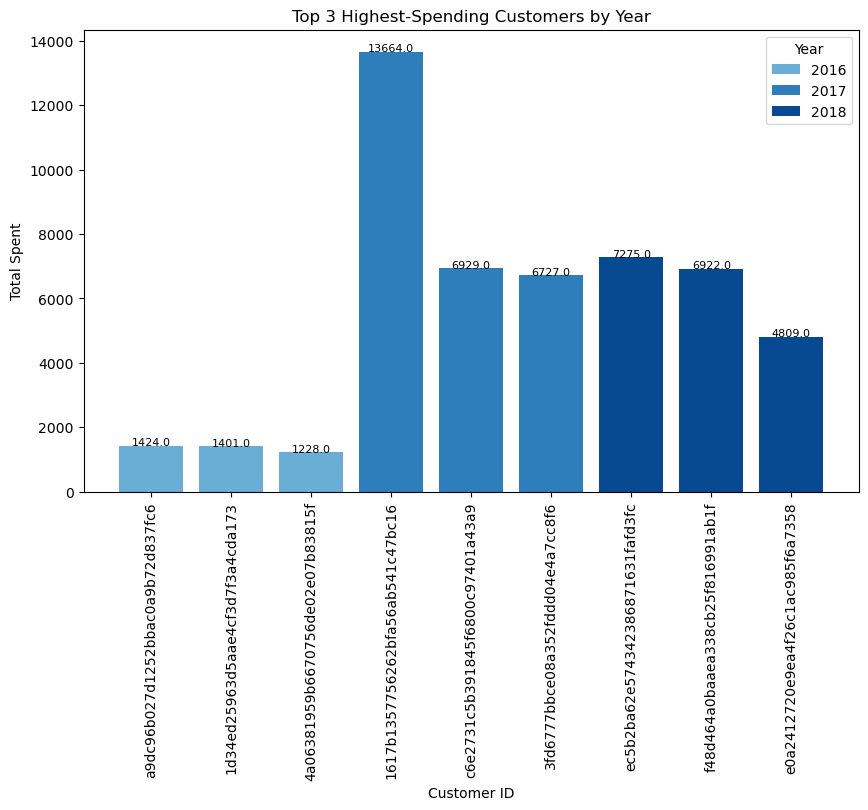

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Execute Query
cursor.execute(query)
data = cursor.fetchall()

# DataFrame
df = pd.DataFrame(data, columns=["year", "customer_id", "total_spent", "rank"])

# Theme colors per year
years = df["year"].unique()
theme_colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(years)))

# Figure
plt.figure(figsize=(10,6))

# Plot bars year-wise
for i, year in enumerate(years):
    yearly_data = df[df["year"] == year]

    bars = plt.bar(
        yearly_data["customer_id"],
        yearly_data["total_spent"],
        color=theme_colors[i],
        label=year
    )

    # Data labels
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval,
            round(yval,0),
            ha='center',
            fontsize=8
        )

# Labels
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")
plt.title("Top 3 Highest-Spending Customers by Year")

plt.xticks(rotation=90)

# Legend
plt.legend(title="Year")

plt.show()